In [ ]:
import hail as hl
import pyspark

tmp_dir = "hdfs://spark-master:9820/"
sc = pyspark.SparkContext()
hadoop_config = sc._jsc.hadoopConfiguration()
hl.init(sc=sc, tmp_dir=tmp_dir, default_reference="GRCh38")

2024-08-13 10:27:15.229 Hail: ERROR: 'Table.filter': source mismatch
  Expected an expression from source <hail.table.Table object at 0x7fdc00a66100>
  Found expression derived from source <hail.table.Table object at 0x7fdc19d54df0>
  Problematic field(s): ['kin']

  This error is commonly caused by chaining methods together:
    >>> ht.distinct().select(ht.x)

  Correct usage:
    >>> ht = ht.distinct()
    >>> ht = ht.select(ht.x)
2024-08-13 10:27:41.262 Hail: INFO: Ordering unsorted dataset with network shuffle
2024-08-13 10:27:53.913 Hail: INFO: Ordering unsorted dataset with network shuffle


In [133]:
from bokeh.io import show, output_notebook
output_notebook()

Loading BokehJS ...

In [11]:
from matplotlib import pyplot as plt
import seaborn
import pandas

# General statistics

In [24]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/gatk_unprocessed.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(48733268, 316)

In [25]:
mt.GT.show()

,,,,,
,,'RefStds_PCR-free8023443','RefStds_PCR-free8023459','RefStds_PCR-free8023475','RefStds_PCR-free8023491'
locus,alleles,GT,GT,GT,GT
locus<GRCh38>,array<str>,call,call,call,call
chr1:10109,"[""AACCCT"",""A""]",0/0,0/0,0/0,0/0
chr1:10135,"[""CCCTAA"",""C""]",NA,NA,NA,NA
chr1:10138,"[""T"",""*"",""TA""]",NA,NA,NA,NA
chr1:10140,"[""ACCCTAAC"",""*"",""A""]",NA,NA,NA,0/0
chr1:10143,"[""CTAACCCCT"",""C"",""*""]",NA,NA,0/0,NA
chr1:10146,"[""AC"",""A"",""*""]",0/1,0/1,0/1,NA
chr1:10147,"[""C"",""*"",""A""]",0/1,0/1,0/1,NA


In [26]:
mt = mt.annotate_rows(call_rate = hl.agg.fraction(hl.is_defined(mt.GT)))
p = hl.plot.histogram(mt.call_rate, range=(0, 1), title='Call rate across all sites')
show(p)

# GIAB samples

In [31]:
samples_set1 = set(['RefStds_PCR-free8023443', 'RefStds_PCR-free8023459', 'RefStds_PCR-free8023475', 'RefStds_PCR-free8023491', 'RefStds_PCR-free8023507'])
samples_set2 = set(['RefStds_PCR-free8023825', 'RefStds_PCR-free8023841', 'RefStds_PCR-free8023857', 'RefStds_PCR-free8023873', 'RefStds_PCR-free8023889'])
samples_set3 = set(['RefStds_PCR8021331', 'RefStds_PCR8021347', 'RefStds_PCR8021363', 'RefStds_PCR8021379', 'RefStds_PCR8021395'])

mt.filter_cols(hl.literal(samples_set1).contains(mt.s)).s.show()

""
s
str
"""RefStds_PCR-free8023443"""
"""RefStds_PCR-free8023459"""
"""RefStds_PCR-free8023475"""
"""RefStds_PCR-free8023491"""
"""RefStds_PCR-free8023507"""


# Sex annotation

In [58]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_sex_annotated.mt'
mt = hl.read_matrix_table(fn)

In [7]:
mt.f_stat.show()

,
s,f_stat
str,float64
"""RefStds_PCR-free8023443""",2.19e-01
"""RefStds_PCR-free8023459""",9.94e-01
"""RefStds_PCR-free8023475""",9.94e-01
"""RefStds_PCR-free8023491""",2.53e-01
"""RefStds_PCR-free8023507""",9.94e-01
"""SLE_WGS13446469""",7.11e-03
"""SLE_WGS13446470""",2.55e-01
"""SLE_WGS13446471""",2.29e-01


In [8]:
p = hl.plot.histogram(mt.f_stat, legend='F statistics')
show(p)

In [59]:
mt.filter_cols(mt.f_stat > 0.5).f_stat.show()

,
s,f_stat
str,float64
"""RefStds_PCR-free8023459""",9.94e-01
"""RefStds_PCR-free8023475""",9.94e-01
"""RefStds_PCR-free8023507""",9.94e-01
"""SLE_map13436180""",7.11e-01


# Relatedness

In [131]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_relatedness.ht'
ht = hl.read_table(fn)
ht = ht.order_by(ht.kin)
ht.show(n=5)

,,,
i,j,,
s,s,kin,ibd2
str,str,float64,float64
"""SLE_WGS13446485""","""SLE_WGS13446620""",5.58e-02,2.07e-02
"""SLE_WGS13446583""","""SLE_WGS13446620""",5.58e-02,1.78e-02
"""SLE_WGS13446586""","""SLE_WGS13446625""",6.17e-02,1.88e-01
"""SLE_WGS13446485""","""SLE_WGS13446622""",6.77e-02,2.91e-02
"""SLE_WGS13446583""","""SLE_WGS13446622""",6.79e-02,2.74e-02


In [134]:
p = hl.plot.histogram(ht.kin, title="Kinship statistics")
show(p)

In [135]:
p = hl.plot.scatter(x=ht.kin, y=ht.ibd2, xlabel='Kinship', ylabel='IBD2', n_divisions=None)
show(p)

/home/ubuntu/venv/lib/python3.9/site-packages/hail/plot/plots.py:929: BokehDeprecationWarning:

'circle() method with size value' was deprecated in Bokeh 3.4.0 and will be removed, use 'scatter(size=...) instead' instead.



In [7]:
ht.filter(ht.kin > 0.4).show()

,,,
i,j,,
s,s,kin,ibd2
str,str,float64,float64
"""SLE_WGS13446490""","""SLE_map13436181""",4.51e-01,8.96e-01
"""SLE_map13436189""","""SLE_map13436216""",4.62e-01,9.28e-01
"""SLE_map13436201""","""SLE_map14783122""",4.65e-01,9.41e-01
"""SLE_map13764350""","""SLE_map13764356""",4.59e-01,9.15e-01


In [22]:
ht.filter(ht.kin > 0.2).show()

,,,
i,j,,
s,s,kin,ibd2
str,str,float64,float64
"""RefStds_PCR-free8023459""","""RefStds_PCR-free8023491""",2.33e-01,4.99e-02
"""RefStds_PCR-free8023459""","""RefStds_PCR-free8023475""",2.33e-01,5.06e-02
"""SLE_WGS13446472""","""SLE_map14749882""",2.76e-01,4.01e-01
"""SLE_map13764395""","""SLE_map14783124""",3.73e-01,6.68e-01
"""SLE_WGS13446490""","""SLE_map13436181""",4.51e-01,8.96e-01
"""SLE_map13764350""","""SLE_map13764356""",4.59e-01,9.15e-01
"""SLE_map13436189""","""SLE_map13436216""",4.62e-01,9.28e-01


In [16]:
test_samples = ["RefStds_PCR-free8023459", "RefStds_PCR-free8023475", "RefStds_PCR-free8023491"]
test_samples = hl.literal(set(test_samples))
ht.filter(test_samples.contains(ht.i.s) | test_samples.contains(ht.j.s)).show()

,,,
i,j,,
s,s,kin,ibd2
str,str,float64,float64
"""RefStds_PCR-free8023459""","""RefStds_PCR-free8023475""",2.33e-01,5.06e-02
"""RefStds_PCR-free8023459""","""RefStds_PCR-free8023491""",2.33e-01,4.99e-02


In [8]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_pca_scores.ht'
ht = hl.read_table(fn)
ht.show(n=5)

,
s,scores
str,array<float64>
"""RefStds_PCR-free8023443""","[1.52e-01,1.03e-01,7.91e-03,-4.89e-02,-9.76e-03,-2.98e-02,1.33e-02,1.14e-03,-1.26e-03,-2.16e-02,3.34e-02,1.33e-02,-3.27e-03,-2.85e-03,-1.82e-03,-3.19e-03,4.54e-03,2.50e-04,-1.91e-04,2.35e-03]"
"""RefStds_PCR-free8023475""","[1.40e-01,8.71e-02,5.43e-03,-2.79e-02,-8.64e-03,-1.51e-02,-1.47e-02,-1.82e-04,-6.68e-03,-2.89e-02,-1.51e-02,-9.01e-03,4.27e-03,-2.43e-03,3.11e-03,2.46e-03,-2.85e-03,-1.29e-05,3.01e-03,-3.50e-03]"
"""RefStds_PCR-free8023491""","[1.37e-01,8.32e-02,4.90e-03,-2.82e-02,-1.13e-02,-1.77e-02,-1.64e-02,2.96e-03,-4.56e-03,-3.28e-02,-1.65e-02,-7.56e-03,4.13e-03,1.45e-03,4.79e-03,4.58e-04,-6.33e-03,-1.80e-03,4.72e-03,-3.38e-04]"
"""RefStds_PCR-free8023507""","[1.15e-01,-3.13e-01,-4.06e-03,-9.19e-02,-3.29e-02,-7.47e-02,-9.03e-04,-6.21e-05,-3.68e-03,-2.62e-03,-4.78e-03,4.00e-03,-1.63e-03,-1.75e-03,-1.36e-03,-9.31e-04,1.97e-04,1.13e-03,-1.30e-03,-1.95e-03]"
"""SLE_WGS13446469""","[-2.29e-01,1.21e-02,-3.52e-02,-1.99e-03,-1.91e-02,8.78e-03,7.14e-03,-2.64e-02,-1.27e-02,-1.04e-04,-2.61e-02,1.71e-01,1.49e-02,4.19e-02,-3.99e-02,-9.29e-02,-1.91e-02,1.30e-01,2.58e-02,1.77e-02]"


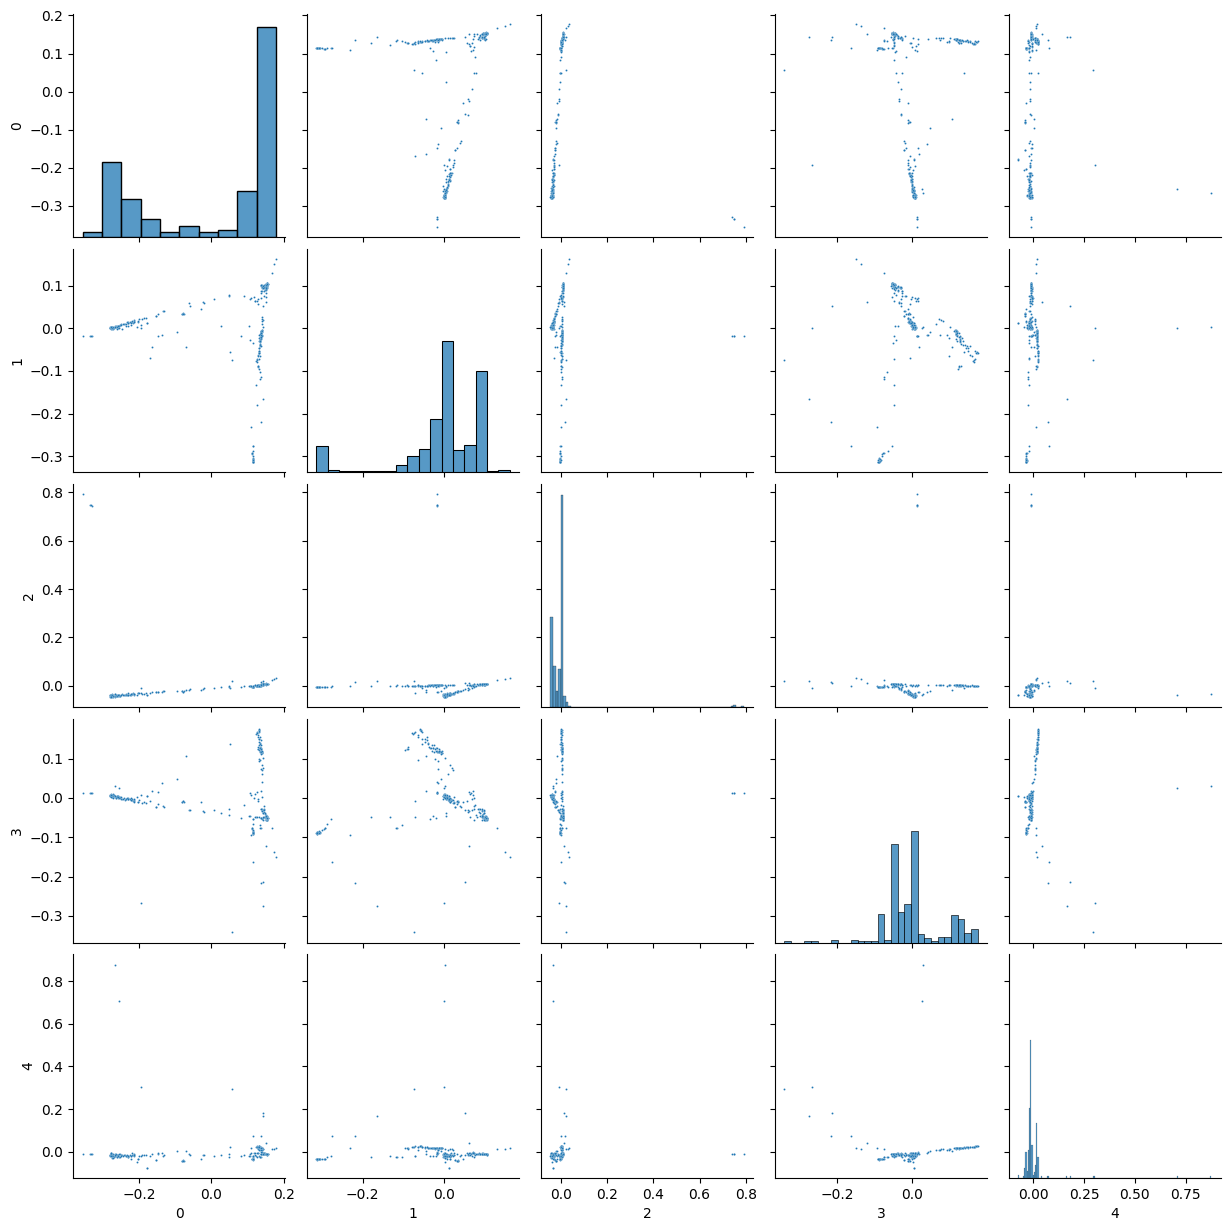

In [12]:
sns_data = pandas.DataFrame.from_records(ht.to_pandas().scores)[range(5)]
p = seaborn.pairplot(sns_data, plot_kws={'s':2})
plt.show()

# Superpopulation prediction

In [23]:
fn = 'file:///lustre/scratch126/teams/hgi/vo3_bib/qc/matrixtables/kg_wes_regions.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(73452337, 2579)

In [35]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/merged_with_1kg.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(2675544, 2895)

In [37]:
2895 - 2579

316

In [42]:
import os.path
mtdir = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/'
fn = os.path.join(mtdir, "pop_assignments.ht")
ht = hl.read_table(fn)
ht.show(n=5)

,,,,,,,,,,
s,known_pop,pca_scores,pop,prob_AFR,prob_AMR,prob_EAS,prob_EUR,prob_SAS,evaluation_sample,training_sample
str,str,array<float64>,str,float64,float64,float64,float64,float64,bool,bool
"""HG00096""","""EUR""","[1.46e-01,2.13e-01,6.11e-02,7.04e-02,-8.60e-03,1.22e-02,2.08e-02,1.21e-03,5.70e-04,1.60e-02]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,True,False
"""HG00097""","""EUR""","[1.43e-01,2.12e-01,5.97e-02,6.68e-02,-5.89e-03,1.06e-02,1.87e-02,-2.76e-03,4.89e-03,1.06e-02]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,False,True
"""HG00099""","""EUR""","[1.43e-01,2.11e-01,6.34e-02,6.32e-02,-6.47e-03,1.05e-02,2.08e-02,2.63e-03,1.10e-02,1.67e-02]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,False,True
"""HG00100""","""EUR""","[1.42e-01,2.16e-01,6.38e-02,6.69e-02,-1.79e-03,5.18e-03,1.16e-02,-2.60e-03,1.11e-02,1.35e-02]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,True,False
"""HG00101""","""EUR""","[1.41e-01,2.12e-01,6.61e-02,6.82e-02,-8.65e-03,1.15e-02,2.31e-02,-9.06e-05,1.04e-02,1.76e-02]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,True,False


In [43]:
ht = ht.filter(hl.is_missing(ht.known_pop))
ht.show(n=5)

,,,,,,,,,,
s,known_pop,pca_scores,pop,prob_AFR,prob_AMR,prob_EAS,prob_EUR,prob_SAS,evaluation_sample,training_sample
str,str,array<float64>,str,float64,float64,float64,float64,float64,bool,bool
"""RefStds_PCR-free8023443""",NA,"[1.43e-01,2.16e-01,6.47e-02,6.29e-02,-3.97e-03,1.40e-02,2.53e-02,1.17e-03,6.29e-03,8.89e-03]","""EUR""",0.00e+00,0.00e+00,0.00e+00,1.00e+00,0.00e+00,False,False
"""RefStds_PCR-free8023459""",NA,"[1.23e-01,1.88e-01,3.23e-02,6.50e-02,1.58e-02,-2.77e-02,-4.63e-02,3.49e-03,-1.59e-03,1.03e-03]","""EUR""",4.00e-02,2.30e-01,6.00e-02,6.70e-01,0.00e+00,False,False
"""RefStds_PCR-free8023475""",NA,"[1.26e-01,1.91e-01,3.55e-02,6.16e-02,1.49e-02,-2.67e-02,-4.80e-02,5.67e-03,1.48e-03,-1.43e-04]","""EUR""",3.00e-02,2.40e-01,5.00e-02,6.80e-01,0.00e+00,False,False
"""RefStds_PCR-free8023491""",NA,"[1.21e-01,1.86e-01,3.38e-02,6.61e-02,1.61e-02,-2.54e-02,-4.19e-02,2.86e-03,-2.65e-03,-6.30e-04]","""EUR""",2.00e-02,2.40e-01,6.00e-02,6.80e-01,0.00e+00,False,False
"""RefStds_PCR-free8023507""",NA,"[1.42e-01,-2.84e-01,4.28e-02,6.01e-02,5.26e-03,-1.08e-02,1.70e-03,-1.28e-03,5.01e-03,3.35e-03]","""EAS""",0.00e+00,0.00e+00,1.00e+00,0.00e+00,0.00e+00,False,False


In [44]:
ht.aggregate(hl.agg.counter(ht.pop))

{'AFR': 113, 'AMR': 16, 'EAS': 23, 'EUR': 84, 'SAS': 65, 'oth': 15}

# Population outliers

In [49]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_pops_sampleqc.ht'
ht = hl.read_table(fn)
ht.show(n=5)

+---------------------------+--------------+-------------------------+
| s                         | assigned_pop | sample_qc.dp_stats.mean |
+---------------------------+--------------+-------------------------+
| str                       | str          |                 float64 |
+---------------------------+--------------+-------------------------+
| "RefStds_PCR-free8023443" | "EUR"        |                5.72e+01 |
| "RefStds_PCR-free8023459" | "EUR"        |                4.94e+01 |
| "RefStds_PCR-free8023475" | "EUR"        |                5.48e+01 |
| "RefStds_PCR-free8023491" | "EUR"        |                4.67e+01 |
| "RefStds_PCR-free8023507" | "EAS"        |                5.05e+01 |
+---------------------------+--------------+-------------------------+

+--------------------------+------------------------+------------------------+
| sample_qc.dp_stats.stdev | sample_qc.dp_stats.min | sample_qc.dp_stats.max |
+--------------------------+------------------------+------------------------+
|                  float64 |                float64 |                float64 |
+--------------------------+------------------------+------------------------+
|                 4.38e+01 |               2.10e+01 |               7.48e+03 |
|                 4.49e+01 |               2.10e+01 |               7.49e+03 |
|                 4.73e+01 |               2.10e+01 |               7.49e+03 |
|                 3.67e+01 |               2.10e+01 |               7.50e+03 |
|                 4.22e+01 |               2.10e+01 |               7.50e+03 |
+--------------------------+------------------------+------------------------+

+-------------------------+--------------------------+------------------------+
| sample_qc.gq_stats.mean | sample_qc.gq_stats.stdev | sample_qc.gq_stats.min |
+-------------------------+--------------------------+------------------------+
|                 float64 |                  float64 |                float64 |
+-------------------------+--------------------------+------------------------+
|                9.78e+01 |                 7.00e+00 |               2.10e+01 |
|                9.76e+01 |                 7.55e+00 |               2.10e+01 |
|                9.77e+01 |                 7.23e+00 |               2.10e+01 |
|                9.74e+01 |                 7.87e+00 |               2.10e+01 |
|                9.77e+01 |                 7.37e+00 |               2.10e+01 |
+-------------------------+--------------------------+------------------------+

+------------------------+---------------------+--------------------+
| sample_qc.gq_stats.max | sample_qc.call_rate | sample_qc.n_called |
+------------------------+---------------------+--------------------+
|                float64 |             float64 |              int64 |
+------------------------+---------------------+--------------------+
|               9.90e+01 |            9.42e-01 |           43989725 |
|               9.90e+01 |            9.35e-01 |           43653023 |
|               9.90e+01 |            9.40e-01 |           43863808 |
|               9.90e+01 |            9.32e-01 |           43520388 |
|               9.90e+01 |            9.37e-01 |           43732761 |
+------------------------+---------------------+--------------------+

+------------------------+----------------------+---------------------+
| sample_qc.n_not_called | sample_qc.n_filtered | sample_qc.n_hom_ref |
+------------------------+----------------------+---------------------+
|                  int64 |                int64 |               int64 |
+------------------------+----------------------+---------------------+
|                      0 |              2696359 |            39331942 |
|                      0 |              3033061 |            39055053 |
|                      0 |              2822276 |            39262031 |
|                      0 |              3165696 |            38938328 |
|                      0 |              2953323 

In [60]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_pops_QC_filters.ht'
ht = hl.read_table(fn)
ht.show(n=5)

+---------------------------+--------------+-------------------------+
| s                         | assigned_pop | sample_qc.dp_stats.mean |
+---------------------------+--------------+-------------------------+
| str                       | str          |                 float64 |
+---------------------------+--------------+-------------------------+
| "RefStds_PCR-free8023443" | "EUR"        |                5.72e+01 |
| "RefStds_PCR-free8023459" | "EUR"        |                4.94e+01 |
| "RefStds_PCR-free8023475" | "EUR"        |                5.48e+01 |
| "RefStds_PCR-free8023491" | "EUR"        |                4.67e+01 |
| "RefStds_PCR-free8023507" | "EAS"        |                5.05e+01 |
+---------------------------+--------------+-------------------------+

+--------------------------+------------------------+------------------------+
| sample_qc.dp_stats.stdev | sample_qc.dp_stats.min | sample_qc.dp_stats.max |
+--------------------------+------------------------+------------------------+
|                  float64 |                float64 |                float64 |
+--------------------------+------------------------+------------------------+
|                 4.38e+01 |               2.10e+01 |               7.48e+03 |
|                 4.49e+01 |               2.10e+01 |               7.49e+03 |
|                 4.73e+01 |               2.10e+01 |               7.49e+03 |
|                 3.67e+01 |               2.10e+01 |               7.50e+03 |
|                 4.22e+01 |               2.10e+01 |               7.50e+03 |
+--------------------------+------------------------+------------------------+

+-------------------------+--------------------------+------------------------+
| sample_qc.gq_stats.mean | sample_qc.gq_stats.stdev | sample_qc.gq_stats.min |
+-------------------------+--------------------------+------------------------+
|                 float64 |                  float64 |                float64 |
+-------------------------+--------------------------+------------------------+
|                9.78e+01 |                 7.00e+00 |               2.10e+01 |
|                9.76e+01 |                 7.55e+00 |               2.10e+01 |
|                9.77e+01 |                 7.23e+00 |               2.10e+01 |
|                9.74e+01 |                 7.87e+00 |               2.10e+01 |
|                9.77e+01 |                 7.37e+00 |               2.10e+01 |
+-------------------------+--------------------------+------------------------+

+------------------------+---------------------+--------------------+
| sample_qc.gq_stats.max | sample_qc.call_rate | sample_qc.n_called |
+------------------------+---------------------+--------------------+
|                float64 |             float64 |              int64 |
+------------------------+---------------------+--------------------+
|               9.90e+01 |            9.42e-01 |           43989725 |
|               9.90e+01 |            9.35e-01 |           43653023 |
|               9.90e+01 |            9.40e-01 |           43863808 |
|               9.90e+01 |            9.32e-01 |           43520388 |
|               9.90e+01 |            9.37e-01 |           43732761 |
+------------------------+---------------------+--------------------+

+------------------------+----------------------+---------------------+
| sample_qc.n_not_called | sample_qc.n_filtered | sample_qc.n_hom_ref |
+------------------------+----------------------+---------------------+
|                  int64 |                int64 |               int64 |
+------------------------+----------------------+---------------------+
|                      0 |              2696359 |            39331942 |
|                      0 |              3033061 |            39055053 |
|                      0 |              2822276 |            39262031 |
|                      0 |              3165696 |            38938328 |
|                      0 |              2953323 

In [55]:
sample_qc_ht = ht.annotate(filter_fail_count=(hl.len(ht.qc_metrics_filters)))
filter_expr = (hl.case()
                   .when(sample_qc_ht.filter_fail_count == 0, 'Pass')
                   .when(sample_qc_ht.filter_fail_count > 0, 'Fail')
                   .default("")
                   )
sample_qc_ht = sample_qc_ht.annotate(filter_result=filter_expr).key_by('s')
res = sample_qc_ht.group_by('assigned_pop').aggregate(counts = hl.agg.counter(sample_qc_ht.filter_result))
res.show()

,
assigned_pop,counts
str,"dict<str, int64>"
"""AFR""","{""Fail"":8,""Pass"":105}"
"""AMR""","{""Fail"":5,""Pass"":11}"
"""EAS""","{""Fail"":3,""Pass"":20}"
"""EUR""","{""Fail"":14,""Pass"":70}"
"""SAS""","{""Fail"":2,""Pass"":63}"
"""oth""","{""Fail"":3,""Pass"":12}"


In [56]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_pops_QC_filters_after_sample_qc.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(48733268, 281)

In [75]:
ht_fail = ht.filter(hl.len(ht.qc_metrics_filters) > 0)
cols = [x for x in ht.row if x.startswith('fail_')]
ht_fail.select('assigned_pop', *cols).show(n=100)

,,,,,,,,,,
s,assigned_pop,fail_heterozygosity_rate,fail_n_snp,fail_r_ti_tv,fail_n_transition,fail_n_transversion,fail_r_insertion_deletion,fail_n_insertion,fail_n_deletion,fail_r_het_hom_var
str,str,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""RefStds_PCR-free8023443""","""EUR""",False,True,False,True,True,False,True,True,False
"""RefStds_PCR-free8023459""","""EUR""",False,True,False,True,True,False,True,True,False
"""RefStds_PCR-free8023475""","""EUR""",False,True,False,True,True,False,True,True,False
"""RefStds_PCR-free8023491""","""EUR""",False,True,False,True,True,False,True,True,False
"""RefStds_PCR-free8023507""","""EAS""",False,True,False,True,True,False,True,True,False
"""SLE_WGS13446472""","""EUR""",True,False,False,False,False,False,False,False,True
"""SLE_WGS13446485""","""EUR""",False,False,False,False,False,False,False,False,True
"""SLE_WGS13446504""","""EUR""",False,False,False,False,False,True,False,False,True


# Variant QC

In [76]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/resources/truthset_table.ht'
ht = hl.read_table(fn)
ht.count()

30744091

In [77]:
ht.show(n=5)

,,,,,
locus,alleles,hapmap,omni,kgp_phase1_hc,mills
locus<GRCh38>,array<str>,bool,bool,bool,bool
chr1:51479,"[""T"",""A""]",NA,NA,True,NA
chr1:55249,"[""C"",""CTATGG""]",NA,NA,NA,True
chr1:55299,"[""C""]",True,NA,NA,NA
chr1:55367,"[""G"",""A""]",NA,NA,True,NA
chr1:55388,"[""C"",""T""]",NA,NA,True,NA


# Genotype QC

In [78]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_varqc_splitmulti.mt'
mt = hl.read_matrix_table(fn)

In [88]:
p = hl.plot.histogram(mt.GQ, legend='Genotype GQ', range=(0, 100))
show(p)

In [92]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/8dd474f1/tmp.hard_filters_combs.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(53070397, 300)

In [89]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/tmphtgx.ht'
ht = hl.read_table(fn)
ht.show()

+---------------+---------------+------+----------+----------+------------+
| locus         | alleles       | rsid |     qual | filters  | info.DPSum |
+---------------+---------------+------+----------+----------+------------+
| locus<GRCh38> | array<str>    | str  |  float64 | set<str> |      int32 |
+---------------+---------------+------+----------+----------+------------+
| chr1:930939   | ["G","A"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:931131   | ["C","CCCCT"] | NA   | 5.00e+01 | {}       |         NA |
| chr1:935954   | ["G","T"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:941119   | ["A","G"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:942335   | ["C","G"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:942451   | ["T","C"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:944858   | ["A","G"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:946247   | ["G","A"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:948245   | ["A","G"]     | NA   | 5.00e+01 | {}       |         NA |
| chr1:948519   | ["T","G"]     | NA   | 5.00e+01 | {}       |         NA |
+---------------+---------------+------+----------+----------+------------+

+----------------+------------------------------------------------+
| info.platforms | info.platformnames                             |
+----------------+------------------------------------------------+
|          int32 | array<str>                                     |
+----------------+------------------------------------------------+
|              4 | ["Illumina","PacBio","CG","10X"]               |
|              4 | ["CG","Illumina","PacBio","10X"]               |
|              6 | ["Illumina","PacBio","CG","10X","Ion","Solid"] |
|              4 | ["Illumina","PacBio","CG","10X"]               |
|              3 | ["Illumina","PacBio","10X"]                    |
|              4 | ["Illumina","PacBio","CG","10X"]               |
|              6 | ["Illumina","PacBio","CG","10X","Ion","Solid"] |
|              5 | ["Illumina","PacBio","CG","10X","Ion"]         |
|              6 | ["Illumina","PacBio","CG","10X","Ion","Solid"] |
|              5 | ["Illumina","PacBio","CG","10X","Ion"]         |
+----------------+------------------------------------------------+

+-------------------+---------------+
| info.platformbias | info.datasets |
+-------------------+---------------+
| array<str>        |         int32 |
+-------------------+---------------+
| NA                |             4 |
| NA                |             4 |
| NA                |             6 |
| NA                |             4 |
| NA                |             3 |
| NA                |             4 |
| NA                |             6 |
| NA                |             5 |
| NA                |             6 |
| NA                |             5 |
+-------------------+---------------+

+------------------------------------------------------------------------------+
| info.datasetnames                                                            |
+------------------------------------------------------------------------------+
| array<str>                                                                   |
+------------------------------------------------------------------------------+
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR"]                    |
| ["CGnormal","HiSeqPE300x","CCS15kb_20kb","10XChromiumLR"]                    |
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR","IonExome","Soli... |
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR"]                    |
| ["HiSeqPE300x","CCS15kb_20kb","10XChromiumLR"]                               |
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR"]                    |
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR","IonExome","Soli... |
| ["HiSeqPE300x","CCS15kb_20kb","CGnormal","10XChromiumLR","IonExome"]         |
| ["HiSeqPE300x","CCS15kb_20kb",

In [90]:
ht.count()

66599

In [94]:
vcf = hl.import_vcf('file:///lustre/scratch126/teams/hgi/ip13/slemap/resources/HG001_GRCh38_benchmark.interval.illumina.vcf.gz', force_bgz=True)
vcf.count()

(66599, 1)

In [96]:
vcf.aggregate_entries(hl.agg.counter(vcf.GT))

{Call(alleles=[0, 1], phased=False): 40607,
 Call(alleles=[1, 1], phased=False): 25992}

In [105]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_varqc_splitmulti.mt'
mt = hl.read_matrix_table(fn)
mt.count()

(53070397, 300)

In [99]:
mt = mt.filter_cols(mt.s == 'RefStds_PCR-free8023443')

In [101]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/resources/HG001_GRCh38_1_22_v4.2.1_benchmark.bed'
bed = hl.import_bed(fn)

In [102]:
mt = mt.filter_rows(hl.is_defined(bed[mt.locus]))
mt.count()

(39772433, 1)

In [104]:
mt = hl.variant_qc(mt)
mt = mt.filter_rows(mt.variant_qc.n_non_ref > 0)
mt.count()

(3779017, 1)

new GIAB VCF

In [107]:
vcf = hl.import_vcf('file:///lustre/scratch126/teams/hgi/ip13/slemap/resources/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz', force_bgz=True)
vcf.count()

(3893341, 1)

In [108]:
vcf = hl.variant_qc(vcf)
vcf = vcf.filter_rows(vcf.variant_qc.n_non_ref > 0)
vcf.count()

(3893341, 1)

# Variant QC tables

In [111]:
run_hash = '8dd474f1'
fn = f'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/variant_qc_random_forest/{run_hash}/_rf_result_ranked_BINS.ht'
ht = hl.read_table(fn)
ht.show()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
rank_id,contig,snv,bi_allelic,singleton,trans_singletons,de_novo_high_quality,de_novo_medium_quality,de_novo_synonymous,bin,min_score,max_score,n,n_ins,n_del,n_ti,n_tv,n_1bp_indel,n_mod3bp_indel,n_singleton,n_high_quality_de_novos,n_medium_quality_de_novos,n_high_confidence_de_novos,n_de_novo,n_high_quality_de_novos_synonymous,n_trans_singletons_synonymous_algorithm,n_untrans_singletons_synonymous_algorithm,n_de_novo_sites,n_trans_singletons,n_trans_singletons_synonymous_hail,n_untrans_singletons,n_untrans_singletons_synonymous_hail,n_train_trans_singletons,n_trans_common,n_untrans_common,n_trans_singletons_synonymous_tdt,n_untrans_singletons_synonymous_tdt,n_omni,n_mills,n_hapmap,n_kgp_high_conf_snvs,fail_hard_filters,fail_hard_filters_snvs,fail_hard_filters_indels
str,str,bool,bool,bool,bool,int64,bool,bool,int32,float64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
"""biallelic_rank""","""chr1""",False,True,False,False,17,True,False,19,2.46e-02,2.46e-02,1,1,0,0,0,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,22,True,False,24,2.53e-02,2.53e-02,1,1,0,0,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,47,True,False,45,3.18e-02,3.18e-02,1,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,62,True,False,53,3.76e-02,3.76e-02,1,0,1,0,0,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,82,True,False,65,1.17e-01,1.17e-01,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,130,True,False,67,1.78e-01,1.78e-01,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,165,True,False,68,1.84e-01,1.84e-01,1,1,0,0,0,0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""biallelic_rank""","""chr1""",False,True,False,False,216,True,False,71,2.04e-01,2.04e-01,1,1,0,0,0,1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [112]:
ht = ht.key_by('rank_id', 'contig', 'snv', 'bi_allelic', 'singleton', 'trans_singletons', 'de_novo_medium_quality', 'de_novo_synonymous', 'bin')
ht = ht.drop('de_novo_high_quality')

ht = ht.group_by(
        *[k for k in ht.key if k != 'contig']
    ).aggregate(
        min_score=hl.agg.min(ht.min_score),
        max_score=hl.agg.max(ht.max_score),
        **{x: hl.agg.sum(ht[x]) for x in ht.row_value if x not in ['min_score', 'max_score']}
    )
ht = ht.annotate(model=run_hash)
df = ht.to_pandas()

In [113]:
df.head()

,rank_id,snv,bi_allelic,singleton,trans_singletons,de_novo_medium_quality,de_novo_synonymous,bin,min_score,max_score,...,n_trans_singletons_synonymous_tdt,n_untrans_singletons_synonymous_tdt,n_omni,n_mills,n_hapmap,n_kgp_high_conf_snvs,fail_hard_filters,fail_hard_filters_snvs,fail_hard_filters_indels,model
0,biallelic_rank,False,True,False,False,False,False,1,0.023243,0.023584,...,0,0,0,14234,1,0,8,0,8,8dd474f1
1,biallelic_rank,False,True,False,False,False,False,2,0.023584,0.023584,...,0,0,0,18109,1,0,0,0,0,8dd474f1
2,biallelic_rank,False,True,False,False,False,False,3,0.023584,0.023584,...,0,0,0,17928,0,0,0,0,0,8dd474f1
3,biallelic_rank,False,True,False,False,False,False,4,0.023584,0.023629,...,0,0,0,13975,0,0,1,0,1,8dd474f1
4,biallelic_rank,False,True,False,False,False,False,5,0.023629,0.02397,...,0,0,0,5240,0,0,28,0,28,8dd474f1


In [116]:
df.to_csv(f'/lustre/scratch126/teams/hgi/ip13/slemap/qc/variant_qc_random_forest/{run_hash}/_rf_result_ranked_BINS.csv', index=False)

In [119]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/variant_qc_random_forest/8dd474f1/_gnomad_score_binning_tmp.ht'
ht = hl.read_table(fn)
ht.show(n=5)

+---------------+------------------+---------+--------------+-------------+
| locus         | alleles          | a_index | variant_type | allele_type |
+---------------+------------------+---------+--------------+-------------+
| locus<GRCh38> | array<str>       |   int32 | str          | str         |
+---------------+------------------+---------+--------------+-------------+
| chr1:10109    | ["AACCCT","A"]   |       1 | "indel"      | "del"       |
| chr1:10109    | ["AACCCT","A"]   |       1 | "indel"      | "del"       |
| chr1:10135    | ["CCCTAA","C"]   |       1 | "indel"      | "del"       |
| chr1:10135    | ["CCCTAA","C"]   |       1 | "indel"      | "del"       |
| chr1:10140    | ["ACCCTAAC","A"] |       2 | "indel"      | "del"       |
+---------------+------------------+---------+--------------+-------------+

+---------------+-----------+-----------+----------+----------+----------+
| n_alt_alleles | was_mixed | was_split | has_star |       MQ |       QD |
+---------------+-----------+-----------+----------+----------+----------+
|         int32 |      bool |      bool |     bool |  float64 |  float64 |
+---------------+-----------+-----------+----------+----------+----------+
|             1 |     False |     False |    False | 3.66e+01 | 2.98e+00 |
|             1 |     False |     False |    False | 3.66e+01 | 2.98e+00 |
|             1 |     False |     False |    False | 4.31e+01 | 1.57e+01 |
|             1 |     False |     False |    False | 4.31e+01 | 1.57e+01 |
|             1 |     False |      True |     True | 3.51e+01 | 1.28e+01 |
+---------------+-----------+-----------+----------+----------+----------+

+-----------+----------+----------------+-----------+--------+------+-------+
| MQRankSum |      SOR | ReadPosRankSum | meanHetAB | hapmap | omni | mills |
+-----------+----------+----------------+-----------+--------+------+-------+
|   float64 |  float64 |        float64 |   float64 |   bool | bool |  bool |
+-----------+----------+----------------+-----------+--------+------+-------+
| -2.82e-01 | 1.96e+00 |       1.59e+00 |  2.73e-01 |     NA |   NA |    NA |
| -2.82e-01 | 1.96e+00 |       1.59e+00 |  2.73e-01 |     NA |   NA |    NA |
|  1.38e+00 | 1.05e-01 |       4.31e-01 |  5.00e-01 |     NA |   NA |    NA |
|  1.38e+00 | 1.05e-01 |       4.31e-01 |  5.00e-01 |     NA |   NA |    NA |
|  0.00e+00 | 1.05e-01 |       7.50e-02 |  4.86e-01 |     NA |   NA |    NA |
+-----------+----------+----------------+-----------+--------+------+-------+

+---------------+-----------------------+-------------------+--------+
| kgp_phase1_hc | transmitted_singleton | fail_hard_filters | ac_raw |
+---------------+-----------------------+-------------------+--------+
|          bool |                  bool |              bool |  int64 |
+---------------+-----------------------+-------------------+--------+
|            NA |                 False |             False |      1 |
|            NA |                 False |             False |      1 |
|            NA |                 False |             False |      1 |
|            NA |                 False |             False |      1 |
|            NA |                 False |             False |     NA |
+---------------+-----------------------+-------------------+--------+

+-------------------------+-------------------------------+--------------------+
| feature_imputed.a_index | feature_imputed.n_alt_alleles | feature_imputed.MQ |
+-------------------------+-------------------------------+--------------------+
|                    bool |                          bool |               bool |
+-------------------------+-------------------------------+--------------------+
|                   False |                         False |              False |
|                   False |                         False |              False |
|                   False |                         False |              False |
|                   False |                     

In [120]:
ht.count()

97673638

In [125]:
ht = ht.filter(ht.rank_id == 'rank')
ht.count()

53070397

In [129]:
ht = ht.select('variant_type', 'allele_type', 'score', 'bin')
ht.show(n=5)

,,,,,
locus,alleles,variant_type,allele_type,score,bin
locus<GRCh38>,array<str>,str,str,float64,int32
chr1:10109,"[""AACCCT"",""A""]","""indel""","""del""",9.88e-01,100
chr1:10135,"[""CCCTAA"",""C""]","""indel""","""del""",6.56e-01,71
chr1:10140,"[""ACCCTAAC"",""A""]","""indel""","""del""",8.32e-01,80
chr1:10143,"[""CTAACCCCT"",""C""]","""indel""","""del""",9.86e-01,98
chr1:10146,"[""AC"",""A""]","""indel""","""del""",8.90e-01,83


In [130]:
ht.export('file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/variant_qc_random_forest/8dd474f1/_gnomad_score_binning_tmp.tsv')

# Wanseon questions

In [137]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/resources/truthset_table.ht'
ht = hl.read_table(fn)
ht.show()

,,,,,
locus,alleles,hapmap,omni,kgp_phase1_hc,mills
locus<GRCh38>,array<str>,bool,bool,bool,bool
chr1:51479,"[""T"",""A""]",NA,NA,True,NA
chr1:55249,"[""C"",""CTATGG""]",NA,NA,NA,True
chr1:55299,"[""C""]",True,NA,NA,NA
chr1:55367,"[""G"",""A""]",NA,NA,True,NA
chr1:55388,"[""C"",""T""]",NA,NA,True,NA
chr1:55394,"[""T""]",True,NA,NA,NA
chr1:55550,"[""A"",""T""]",True,NA,NA,NA
chr1:55852,"[""G"",""C""]",NA,NA,True,NA


In [143]:
ht.aggregate(hl.agg.counter(ht.kgp_phase1_hc))

{True: 28574948, None: 2169143}

In [139]:
ht.count()

30744091

In [148]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/ht_for_RF_all_cols.ht'
ht = hl.read_table(fn)
ht = ht.annotate(
    fp = ht.fail_hard_filters,
    tp = ht.omni | ht.mills | ht.kgp_phase1_hc | ht.hapmap
)
ht.show()

,,,,,,,,,,,,,,,,,,,,,,,
locus,alleles,a_index,variant_type,allele_type,n_alt_alleles,was_mixed,was_split,has_star,MQ,QD,MQRankSum,SOR,ReadPosRankSum,meanHetAB,hapmap,omni,mills,kgp_phase1_hc,transmitted_singleton,fail_hard_filters,ac_raw,fp,tp
locus<GRCh38>,array<str>,int32,str,str,int32,bool,bool,bool,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,bool,int64,bool,bool
chr1:10109,"[""AACCCT"",""A""]",1,"""indel""","""del""",1,False,False,False,3.66e+01,2.98e+00,-2.82e-01,1.96e+00,1.59e+00,2.73e-01,NA,NA,NA,NA,False,False,1,False,NA
chr1:10135,"[""CCCTAA"",""C""]",1,"""indel""","""del""",1,False,False,False,4.31e+01,1.57e+01,1.38e+00,1.05e-01,4.31e-01,5.00e-01,NA,NA,NA,NA,False,False,1,False,NA
chr1:10140,"[""ACCCTAAC"",""A""]",2,"""indel""","""del""",1,False,True,True,3.51e+01,1.28e+01,NA,1.05e-01,NA,NA,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10143,"[""CTAACCCCT"",""C""]",1,"""indel""","""del""",1,False,True,True,3.90e+01,3.21e+00,6.89e-01,2.83e-01,0.00e+00,1.82e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10146,"[""AC"",""A""]",1,"""indel""","""del""",1,False,True,True,3.78e+01,2.28e+01,6.74e-01,1.08e+00,6.95e-01,6.85e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10150,"[""C"",""T""]",2,"""snv""","""snv""",1,False,True,True,3.76e+01,6.84e+00,-1.83e+00,3.68e-01,-4.31e-01,3.33e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10151,"[""TA"",""T""]",3,"""mixed""","""del""",2,True,True,True,3.78e+01,2.11e+01,9.67e-01,3.30e-01,9.67e-01,6.67e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10152,"[""A"",""G""]",2,"""snv""","""snv""",1,False,True,True,3.03e+01,8.22e+00,1.05e-01,1.98e+00,-1.05e-01,3.00e-01,NA,NA,NA,NA,False,False,NA,False,NA


In [149]:
ht.aggregate(hl.agg.counter(ht.fp))

{False: 49826478, True: 3243865, None: 54}

In [150]:
ht.aggregate(hl.agg.counter(ht.tp))

{True: 20040052, None: 33030345}

In [153]:
ht_indel = ht.filter(ht.variant_type == 'indel')
hl.len(ht_indel.alleles).show()

,,
locus,alleles,<expr>
locus<GRCh38>,array<str>,int32
chr1:10109,"[""AACCCT"",""A""]",2
chr1:10135,"[""CCCTAA"",""C""]",2
chr1:10140,"[""ACCCTAAC"",""A""]",2
chr1:10143,"[""CTAACCCCT"",""C""]",2
chr1:10146,"[""AC"",""A""]",2
chr1:10156,"[""CTAACCCTAACCCTAACCCTAACCT"",""C""]",2
chr1:10172,"[""CCCTAA"",""C""]",2
chr1:10178,"[""CCTAA"",""C""]",2


In [156]:
ht_indel = ht_indel.annotate(max_allele_length=hl.max(hl.map(hl.len, ht_indel.alleles)))

max_length = ht_indel.aggregate(hl.agg.max(ht_indel.max_allele_length))
print(f"Maximum allele length: {max_length}")

Maximum allele length: 673


In [163]:
ht_indel2 = ht.filter(hl.len(ht.alleles[0]) != hl.len(ht.alleles[1]))
ht_indel2.aggregate(hl.agg.counter(ht_indel2.variant_type))

{'indel': 4455198, 'mixed': 1055257, 'multi-indel': 4747628}

In [165]:
ht_indel2.filter(ht_indel2.variant_type == 'multi-indel').show()

,,,,,,,,,,,,,,,,,,,,,,,
locus,alleles,a_index,variant_type,allele_type,n_alt_alleles,was_mixed,was_split,has_star,MQ,QD,MQRankSum,SOR,ReadPosRankSum,meanHetAB,hapmap,omni,mills,kgp_phase1_hc,transmitted_singleton,fail_hard_filters,ac_raw,fp,tp
locus<GRCh38>,array<str>,int32,str,str,int32,bool,bool,bool,float64,float64,float64,float64,float64,float64,bool,bool,bool,bool,bool,bool,int64,bool,bool
chr1:10468,"[""T"",""TAACCCTAACCCTAACCCTAACCCTAACCC""]",2,"""multi-indel""","""ins""",2,False,True,False,3.74e+01,1.87e+01,0.00e+00,3.68e-01,-9.67e-01,NA,NA,NA,NA,NA,False,False,NA,False,NA
chr1:10468,"[""TCGCGG"",""T""]",1,"""multi-indel""","""del""",2,False,True,False,3.74e+01,1.87e+01,0.00e+00,3.68e-01,-9.67e-01,4.17e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:30867,"[""CCT"",""C""]",1,"""multi-indel""","""del""",2,False,True,False,4.60e+01,4.33e+00,-2.02e+00,7.66e-01,-6.30e-02,1.82e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:30867,"[""CCTCT"",""C""]",2,"""multi-indel""","""del""",2,False,True,False,4.60e+01,4.33e+00,-2.02e+00,7.66e-01,-6.30e-02,4.29e-01,NA,NA,NA,NA,False,False,NA,False,NA
chr1:31719,"[""G"",""GA""]",1,"""multi-indel""","""ins""",2,False,True,False,2.40e+01,1.49e+01,-6.74e-01,6.31e-01,6.74e-01,4.52e-01,NA,NA,NA,NA,False,True,NA,True,NA
chr1:31719,"[""GAA"",""G""]",2,"""multi-indel""","""del""",2,False,True,False,2.40e+01,1.49e+01,-6.74e-01,6.31e-01,6.74e-01,6.67e-01,NA,NA,NA,NA,False,True,NA,True,NA
chr1:33520,"[""G"",""GAT""]",1,"""multi-indel""","""ins""",2,False,True,False,2.48e+01,3.05e+01,-6.74e-01,4.23e+00,-3.19e-01,4.38e-01,NA,NA,NA,NA,False,True,NA,True,NA
chr1:33520,"[""GT"",""G""]",2,"""multi-indel""","""del""",2,False,True,False,2.48e+01,3.05e+01,-6.74e-01,4.23e+00,-3.19e-01,NA,NA,NA,NA,NA,False,True,NA,True,NA


In [177]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/variant_qc_random_forest/8dd474f1/training.ht'
ht = hl.read_table(fn)
ht.show()

+---------------+-----------------------------------+---------+--------------+
| locus         | alleles                           | a_index | variant_type |
+---------------+-----------------------------------+---------+--------------+
| locus<GRCh38> | array<str>                        |   int32 | str          |
+---------------+-----------------------------------+---------+--------------+
| chr1:10109    | ["AACCCT","A"]                    |       1 | "indel"      |
| chr1:10135    | ["CCCTAA","C"]                    |       1 | "indel"      |
| chr1:10140    | ["ACCCTAAC","A"]                  |       2 | "indel"      |
| chr1:10143    | ["CTAACCCCT","C"]                 |       1 | "indel"      |
| chr1:10146    | ["AC","A"]                        |       1 | "indel"      |
| chr1:10150    | ["C","T"]                         |       2 | "snv"        |
| chr1:10151    | ["TA","T"]                        |       3 | "mixed"      |
| chr1:10152    | ["A","G"]                         |       2 | "snv"        |
| chr1:10156    | ["CTAACCCTAACCCTAACCCTAACCT","C"] |       1 | "indel"      |
| chr1:10165    | ["A","G"]                         |       2 | "snv"        |
+---------------+-----------------------------------+---------+--------------+

+-------------+---------------+-----------+-----------+----------+----------+
| allele_type | n_alt_alleles | was_mixed | was_split | has_star |       MQ |
+-------------+---------------+-----------+-----------+----------+----------+
| str         |         int32 |      bool |      bool |     bool |  float64 |
+-------------+---------------+-----------+-----------+----------+----------+
| "del"       |             1 |     False |     False |    False | 3.66e+01 |
| "del"       |             1 |     False |     False |    False | 4.31e+01 |
| "del"       |             1 |     False |      True |     True | 3.51e+01 |
| "del"       |             1 |     False |      True |     True | 3.90e+01 |
| "del"       |             1 |     False |      True |     True | 3.78e+01 |
| "snv"       |             1 |     False |      True |     True | 3.76e+01 |
| "del"       |             2 |      True |      True |     True | 3.78e+01 |
| "snv"       |             1 |     False |      True |     True | 3.03e+01 |
| "del"       |             1 |     False |     False |    False | 3.13e+01 |
| "snv"       |             1 |     False |      True |     True | 4.63e+01 |
+-------------+---------------+-----------+-----------+----------+----------+

+----------+-----------+----------+----------------+-----------+--------+------+
|       QD | MQRankSum |      SOR | ReadPosRankSum | meanHetAB | hapmap | omni |
+----------+-----------+----------+----------------+-----------+--------+------+
|  float64 |   float64 |  float64 |        float64 |   float64 |   bool | bool |
+----------+-----------+----------+----------------+-----------+--------+------+
| 2.98e+00 | -2.82e-01 | 1.96e+00 |       1.59e+00 |  2.73e-01 |     NA |   NA |
| 1.57e+01 |  1.38e+00 | 1.05e-01 |       4.31e-01 |  5.00e-01 |     NA |   NA |
| 1.28e+01 |  0.00e+00 | 1.05e-01 |       7.50e-02 |  4.86e-01 |     NA |   NA |
| 3.21e+00 |  6.89e-01 | 2.83e-01 |       0.00e+00 |  1.82e-01 |     NA |   NA |
| 2.28e+01 |  6.74e-01 | 1.08e+00 |       6.95e-01 |  6.85e-01 |     NA |   NA |
| 6.84e+00 | -1.83e+00 | 3.68e-01 |      -4.31e-01 |  3.33e-01 |     NA |   NA |
| 2.11e+01 |  9.67e-01 | 3.30e-01 |       9.67e-01 |  6.67e-01 |     NA |   NA |
| 8.22e+00 |  1.05e-01 | 1.98e+00 |      -1.05e-01 |  3.00e-01 |     NA |   NA |
| 1.32e+01 |  2.37e+00 | 1.33e+00 |       1.98e+00 |  6.25e-01 |     NA |   NA |
| 1.44e+01 |  9.67e-01 | 1.61e+00 |       9.67e-01 |  6.67e-01 |     NA |   NA |
+----------+-----------+----------+----------------+-----------+--------+------+

+-------+---------------+-----------------------+-------------------+--------+
| mills | kgp_phase1_hc | transmitted_singleton | fail_hard_filters | ac_raw |
+-------+---------------+------

In [178]:
ht.aggregate(hl.agg.counter(ht.rf_train))

{False: 17040537, True: 6219671, None: 29810189}

In [179]:
train_ht = ht.filter(ht.rf_train)
train_ht.count()

6219671

In [180]:
train_ht.aggregate(hl.agg.counter(train_ht.locus.contig))

{'chr1': 634241,
 'chr10': 310426,
 'chr11': 298341,
 'chr12': 278943,
 'chr13': 293561,
 'chr14': 175974,
 'chr15': 190225,
 'chr16': 197291,
 'chr17': 178817,
 'chr18': 180025,
 'chr19': 137518,
 'chr2': 486524,
 'chr21': 125846,
 'chr22': 133853,
 'chr3': 391135,
 'chr4': 368755,
 'chr5': 361478,
 'chr6': 307853,
 'chr7': 334703,
 'chr8': 286918,
 'chr9': 307803,
 'chrX': 209678,
 'chrY': 29763}

In [181]:
sumary = train_ht.group_by(train_ht.variant_type, train_ht.tp, train_ht.fp).aggregate(n=hl.agg.count())
sumary.show()

,,,
variant_type,tp,fp,n
str,bool,bool,int64
"""indel""",True,False,141537
"""indel""",NA,True,404210
"""mixed""",True,False,11340
"""mixed""",NA,True,125588
"""multi-indel""",True,False,20484
"""multi-indel""",NA,True,306845
"""multi-snv""",True,False,21185
"""multi-snv""",NA,True,193250


In [176]:
train_ht.aggregate(hl.agg.counter(train_ht.rf_label))

{'FP': 3108848, 'TP': 3110823}

In [182]:
test_ht = ht.filter(ht.rf_test)
test_ht.aggregate(hl.agg.counter(test_ht.locus.contig))

{'chr20': 1281597}

In [183]:
test_ht.aggregate(hl.agg.counter(test_ht.rf_label))

{'FP': 111308, 'TP': 446102, None: 724187}

# Generate VCFs

In [184]:
fn = 'file:///lustre/scratch126/teams/hgi/ip13/slemap/qc/matrixtables/mt_after_var_qc.mt'
mt = hl.read_matrix_table(fn)

In [191]:
mt2 = mt.filter_rows(hl.is_indel(mt.alleles[0], mt.alleles[1]))

In [192]:
mt2.count()

(0, 300)